# Notebook 5: who won?

M/EEG foundation models workshop · *Do foundation models beat classical EEG decoding?*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BabaSanfour/meeg-fm-workshop/blob/main/notebooks/05_compare.ipynb)

<table style="width:100%; border-collapse:separate; border-spacing:0; margin:6px 0 10px 0;"><tr><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 0</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Setup</div><div style="font-size:0.85em; color:#5B6472;">check · install · download</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 1</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Meet the data</div><div style="font-size:0.85em; color:#5B6472;">BCI IV 2a · epochs · mu and beta rhythms</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 2</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Classical baselines</div><div style="font-size:0.85em; color:#5B6472;">CSP + LDA · tangent space</div></td></tr><tr><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 3</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Frozen REVE</div><div style="font-size:0.85em; color:#5B6472;">embeddings · linear probe · few labels</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 4</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Fine-tuning</div><div style="font-size:0.85em; color:#5B6472;">demo · GPU optional</div></td><td style="background:#0B2545; color:#FFFFFF; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#C9D6E8;">NOTEBOOK 5</div><div style="font-weight:bold; font-size:1.05em; color:#FFFFFF;">Who won?</div><div style="font-size:0.85em; color:#C9D6E8;">one table · per person · statistics</div></td></tr></table>

Notebooks 2 to 4 trained four decoders on the same trials and saved their scores. This notebook puts the scores side by side and asks what we are allowed to conclude from them. It trains nothing: it reads the saved tables, so it runs in a few seconds. It needs notebooks 2, 3 and 4 to have been run.

| Part | Content |
|---|---|
| 1 | Gather the scores |
| 2 | One table |
| 3 | Participant by participant |
| 4 | Is the difference real? |
| 5 | Under which conditions? |
| 6 | So, who won? |
| 7 | Go further (optional) |
| 8 | Summary |

<div style="color:#1F2937; background:#F9FAFB; border:1px solid #E5E7EB; border-radius:6px; padding:8px 14px;"><b>Three kinds of blocks</b><div style="margin:3px 0;"><span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> &nbsp;the code is complete: run the cell and read the comments.</div><div style="margin:3px 0;"><span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> &nbsp;complete the one or two lines marked <code>&lt;---</code>.</div><div style="margin:3px 0;"><span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> &nbsp;optional: write the cell yourself, from hints and links to the documentation.</div><div style="font-size:0.9em; color:#5B6472; margin-top:4px;">Each exercise is followed by a folded solution. Run the solution before moving on: the next cells use its variables. Type 3 blocks can wait until after the session.</div></div>

In [1]:
#@title Setup: install on Colab, imports, results folder
import sys
import importlib

REPO_URL = "https://github.com/BabaSanfour/meeg-fm-workshop"   # the tutorial repository
USE_DRIVE = True                                     # Colab: read the results that the other notebooks saved in your Drive

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip install -q "git+{REPO_URL}.git"
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")                # a window asks for permission
    importlib.invalidate_caches()

try:
    import meeg_fm as mf                     # the tutorial package: saved fine-tuning runs
except ImportError:
    raise ImportError("The tutorial package is missing. Colab: Runtime › Restart session, then Run all. "
                      "Your computer: run `pip install -e .` in the repository folder, then restart the kernel.")

from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import balanced_accuracy_score

mf.plot.style()
RESULTS_DIR = (mf.use_data_dir() if IN_COLAB else Path(".")) / "results"
print("Results folder:", RESULTS_DIR.resolve())

Results folder: results


In [2]:
# ---- Parameters
REFERENCE = "Tangent space + LR"             # the decoder every other one is compared with: the best classical one
N_TEST = 144                                 # test trials per participant (day 2)
N_BOOTSTRAP = 10_000                         # resamplings for the confidence intervals
METHODS = ["CSP + LDA", "Tangent space + LR", "REVE frozen + LR", "REVE fine-tuned"]

## 1. Gather the scores

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>Four decoders, the same nine participants, the same test day: the scores are in a few small tables saved by notebooks 2 to 4.</div>

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: why it matters</b><br>A table of means invites a quick conclusion. With nine participants and four decoders trained under different conditions, the conclusion depends on how the table is read. This notebook checks what the scores support.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Read what the other notebooks saved

Each notebook wrote one row per decoder and participant: the scores on day 2, and how the decoder was trained.

In [3]:
# ---- One table with every decoder and participant
SOURCES = {"classical.csv": "02_classical.ipynb", "fm_frozen.csv": "03_fm_frozen.ipynb",
           "fm_finetuned.csv": "04_fm_finetune.ipynb"}
missing = [f"{name} (run {notebook})" for name, notebook in SOURCES.items() if not (RESULTS_DIR / name).exists()]
if missing:
    raise FileNotFoundError("Missing results: " + ", ".join(missing))

scores = pd.concat(pd.read_csv(RESULTS_DIR / name) for name in SOURCES)
SUBJECTS = sorted(scores["subject"].unique())
print(len(scores), "rows:", scores["method"].nunique(), "decoders ×", len(SUBJECTS), "participants")
scores.groupby("method", sort=False).head(1).drop(columns=["subject", "balanced_accuracy", "auc", "seconds"])

36 rows: 4 decoders × 9 participants


,method,training_data,training_labels,adapted_parameters,hardware
0,CSP + LDA,own day 1,100 %,none,CPU
9,Tangent space + LR,own day 1,100 %,none,CPU
0,REVE frozen + LR,own day 1,100 %,head only,CPU
0,REVE fine-tuned,everyone's day 1,100 %,all,GPU


The four rows above show how each decoder was trained. Three of them learn from the day 1 of one participant. The fine-tuned REVE learns from the day 1 of all nine participants together, and needs a GPU. Keep this in mind for the rest of the notebook: part 5 comes back to it.

## 2. One table

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>One table gives the ranking. The columns next to the score say under which conditions each score was obtained.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> The table of the tutorial

In [4]:
# ---- Mean scores and cost of each decoder
summary = scores.groupby("method", sort=False).agg(
    balanced_accuracy=("balanced_accuracy", "mean"), auc=("auc", "mean"), seconds=("seconds", "sum"),
    training_data=("training_data", "first"), training_labels=("training_labels", "first"),
    adapted_parameters=("adapted_parameters", "first"), hardware=("hardware", "first")).loc[METHODS]
summary["balanced_accuracy"] = (100 * summary["balanced_accuracy"]).round(1)
summary["auc"] = summary["auc"].round(2)
summary["seconds"] = summary["seconds"].round(1)
summary["test data seen in pretraining?"] = ["no pretraining", "no pretraining", "no, according to the REVE paper",
                                             "no, according to the REVE paper"]
summary.rename(columns={"balanced_accuracy": "balanced accuracy (%)", "auc": "ROC AUC", "seconds": "training time (s)"})

,balanced accuracy (%),ROC AUC,training time (s),training_data,training_labels,adapted_parameters,hardware,test data seen in pretraining?
method,,,,,,,,
CSP + LDA,72.8,0.82,1.2,own day 1,100 %,none,CPU,no pretraining
Tangent space + LR,76.5,0.87,2.2,own day 1,100 %,none,CPU,no pretraining
REVE frozen + LR,70.7,0.79,0.4,own day 1,100 %,head only,CPU,"no, according to the REVE paper"
REVE fine-tuned,85.0,0.94,280.2,everyone's day 1,100 %,all,GPU,"no, according to the REVE paper"


Read the score together with the training columns. The fine-tuned REVE has the highest score, 85 %, and it is also the only decoder trained on nine participants and on a GPU. Among the decoders trained on one participant, tangent space + LR is first (76.5 %) and the frozen REVE last (70.7 %).

<div style="border-left:5px solid #E8710A; background:#FDF1E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#E8710A;">Watch out: was the test data in the pretraining?</b><br>The last column matters for any foundation model. If the recordings used for testing were part of the pretraining data, even without their labels, the model has an advantage that says nothing about new data. The REVE paper states that the datasets used for evaluation were removed from pretraining, and BCI IV 2a is one of them. An independent benchmark, NeuralBench, reports overlaps for other datasets. Always check, and expect the answer to be hard to find.</div>

## 3. Participant by participant

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>Look at each participant before the mean, and remember that guessing can reach 57 % with 144 trials.</div>

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: per-participant scores and the chance level</b><br>A mean over nine people can hide opposite stories: a decoder may be far better for three people and slightly worse for six. We always look at the scores of each participant before reading the mean.<br>A second point: <b>chance is not exactly 50 %</b>. With 144 test trials, a decoder that guesses will, by luck, sometimes reach 55 %. The <b>binomial distribution</b> tells how high guessing gets: a score has to pass a threshold above 50 % before we can say the decoder found something (Combrisson and Jerbi, 2015).</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> How high can guessing get?

In [5]:
# ---- The score that guessing reaches less than 5 % of the time, with 144 test trials
threshold = stats.binom.ppf(0.95, N_TEST, 0.5) / N_TEST
print(f"With {N_TEST} trials, guessing stays below {100 * threshold:.1f} % in 95 % of cases.")
print(f"With 20 trials the same threshold would be {100 * stats.binom.ppf(0.95, 20, 0.5) / 20:.0f} %.")

With 144 trials, guessing stays below 56.9 % in 95 % of cases.
With 20 trials the same threshold would be 70 %.


### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Every decoder, every participant

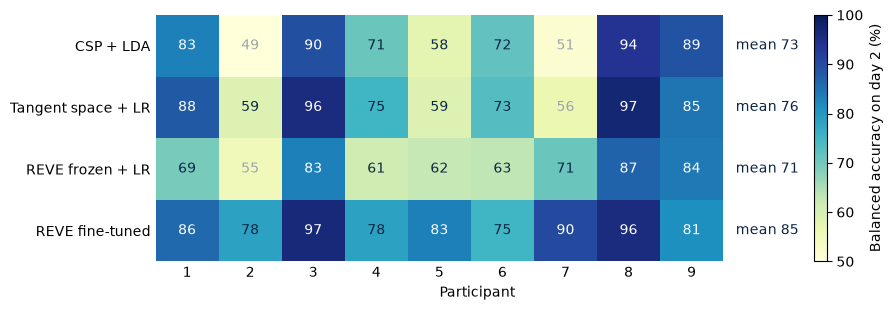

In [6]:
# ---- Balanced accuracy on day 2 as a table of colours; scores that guessing could reach are in grey
table = scores.pivot(index="method", columns="subject", values="balanced_accuracy").loc[METHODS, SUBJECTS]
mf.plot.score_table(table, threshold)

Grey numbers are scores that guessing could reach (below 56.9 %): participant 2 with CSP + LDA and with the frozen REVE, participant 7 with both classical decoders. The fine-tuned model is the only one above the threshold for all nine people; its lowest score is 75 %. Participants 3 and 8 are above 83 % with every decoder: for them the choice of decoder matters little. The mean of each row comes mostly from what happens to participants 2, 5 and 7.

## 4. Is the difference real?

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>With nine participants, a gain of 8.6 points can still fail a statistical test when it comes from three people.</div>

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: paired comparison, confidence interval, p-value</b><br>The four decoders were tested on the <b>same</b> nine participants, so we compare them participant by participant: for each person, the score of one decoder minus the score of another. This is a <b>paired comparison</b>. It removes the large differences between people, which would otherwise drown the difference between decoders.<br>Nine participants are a small sample. Another nine people would give another mean difference. Two tools tell how far we can trust ours. A <b>confidence interval</b> gives the range of mean differences compatible with the data. A <b>statistical test</b> gives a <b>p-value</b>: how often a difference at least this large would appear if the two decoders were in fact equally good.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> The differences with the best classical decoder

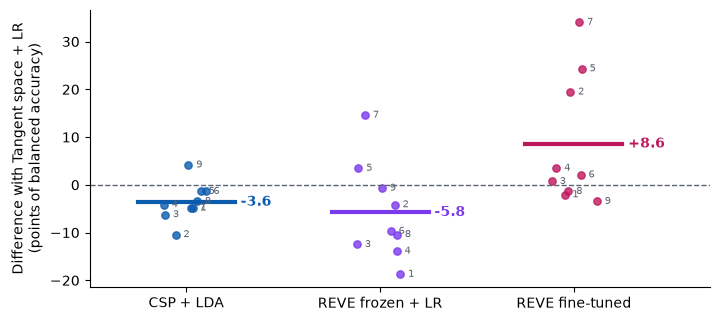

In [7]:
# ---- For each participant: score of each decoder minus the score of tangent space + LR
differences = 100 * (table.drop(index=REFERENCE) - table.loc[REFERENCE])
mf.plot.differences(differences, REFERENCE)

Each dot is one participant, with their number; the thick line is the mean difference. Above the dashed line, the decoder does better than tangent space + LR for that person.

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> A confidence interval by bootstrap

The **bootstrap** imitates "another nine people" with the data we have: draw nine participants at random among ours, with repetition, compute the mean difference, and repeat thousands of times. The middle 95 % of these means is the confidence interval. Complete the two lines for the fine-tuned REVE.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>rng.choice(values, size=(N_BOOTSTRAP, len(values)))</code> draws all the resamples at once, one per row (repetition is the default). Take the mean of each row, then <code>np.percentile(means, [2.5, 97.5])</code>.</div>

In [8]:
# ---- Exercise: bootstrap confidence interval of the mean difference, fine-tuned REVE against the reference
values = differences.loc["REVE fine-tuned"].to_numpy()
rng = np.random.default_rng(0)
means = ...                                          # <--- N_BOOTSTRAP resamples of the 9 values, mean of each
interval = ...                                       # <--- the 2.5th and 97.5th percentiles of `means`

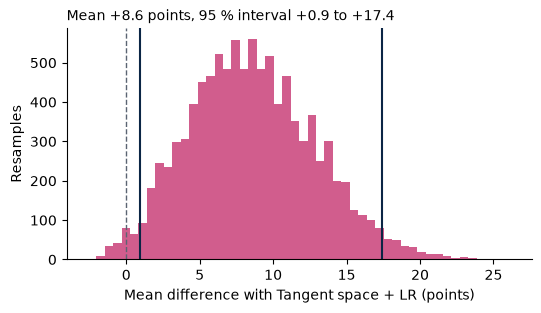

In [9]:
#@title Solution (try first)
# ---- Bootstrap confidence interval of the mean difference, fine-tuned REVE against the reference
values = differences.loc["REVE fine-tuned"].to_numpy()
rng = np.random.default_rng(0)
means = rng.choice(values, size=(N_BOOTSTRAP, len(values))).mean(axis=1)
interval = np.percentile(means, [2.5, 97.5])

mf.plot.bootstrap(means, interval, values.mean(), REFERENCE)

The mean gain is +8.6 points, and the interval goes from about +1 to +17 points. It is wide because the gain is uneven: three participants gain 19 to 34 points, and the six others change by 4 points or less, three of them downwards.

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> A test for paired data

The **Wilcoxon signed-rank test** asks whether the differences are balanced around zero. It ranks them by size and compares the ranks of the positive and negative ones, so one very large difference does not decide the result alone. Run it on the same nine values.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>stats.wilcoxon(values)</code> tests whether the values are centred on 0 and returns the statistic and the p-value (<a href='https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html'>documentation</a>).</div>

In [10]:
# ---- Exercise: Wilcoxon signed-rank test on the nine differences
result = ...                                         # <--- stats.wilcoxon on `values`

In [11]:
#@title Solution (try first)
# ---- Wilcoxon signed-rank test on the nine differences
result = stats.wilcoxon(values)
print(f"Fine-tuned REVE against {REFERENCE}: p = {result.pvalue:.3f}")

Fine-tuned REVE against Tangent space + LR: p = 0.172


### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Every decoder against the reference

The same two tools for the three comparisons. When several tests are run, one of them can pass by luck, so the p-values are corrected: the **Holm correction** multiplies the smallest p-value by the number of tests, the next by one less, and so on.

In [12]:
# ---- Mean difference, bootstrap interval and corrected p-value for each decoder
def compare(values, rng):
    """Mean of paired differences, its bootstrap 95 % interval, and the Wilcoxon p-value."""
    means = rng.choice(values, size=(N_BOOTSTRAP, len(values))).mean(axis=1)
    low, high = np.percentile(means, [2.5, 97.5])
    return {"mean difference": values.mean(), "95 % low": low, "95 % high": high, "p": stats.wilcoxon(values).pvalue}


rng = np.random.default_rng(0)
comparison = pd.DataFrame({method: compare(row.to_numpy(), rng) for method, row in differences.iterrows()}).T
order = comparison["p"].sort_values().index                              # Holm: smallest p-value first
holm = np.maximum.accumulate([min(1, comparison.loc[m, "p"] * (len(order) - k)) for k, m in enumerate(order)])
comparison.loc[order, "p (Holm)"] = holm
comparison["participants better / worse"] = [f"{(row > 0).sum()} / {(row < 0).sum()}" for _, row in differences.iterrows()]
comparison.round(3)

,mean difference,95 % low,95 % high,p,p (Holm),participants better / worse
CSP + LDA,-3.627,-6.019,-1.157,0.023,0.070,1 / 8
REVE frozen + LR,-5.787,-11.651,0.849,0.164,0.328,2 / 7
REVE fine-tuned,8.565,0.772,17.515,0.172,0.328,6 / 3


<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">What we see</b><br><b>CSP + LDA</b> is 3.6 points below tangent space + LR, in 8 of 9 participants. The interval excludes 0 and the p-value is 0.02, 0.07 after correction: a small and consistent difference.<br><b>Frozen REVE</b> is 5.8 points below on average, with an interval that includes 0.<br><b>Fine-tuned REVE</b> is 8.6 points above. Its interval just excludes 0, but the Wilcoxon p-value is 0.17, well above the usual 0.05. The two tools disagree because they look at different things. The bootstrap looks at the mean, which three large gains pull up. The Wilcoxon test looks at how consistently the differences go one way, and here six go up and three go down.<br>What we can say with nine participants: fine-tuning was much better for the three people the classical decoders could not decode, and about equal for the six others. We cannot claim that it is better for a new person in general. A comparison of classifiers needs more than a difference of means (Demšar, 2006).</div>

## 5. Under which conditions?

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>Each decoder has conditions under which it is the best choice.</div>

One number per decoder hides the conditions under which it was obtained. Notebooks 3 and 4 varied three of them: who the training data comes from, how many labelled trials there are, and how much computing the decoder needs.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Three ways to look at the same decoders

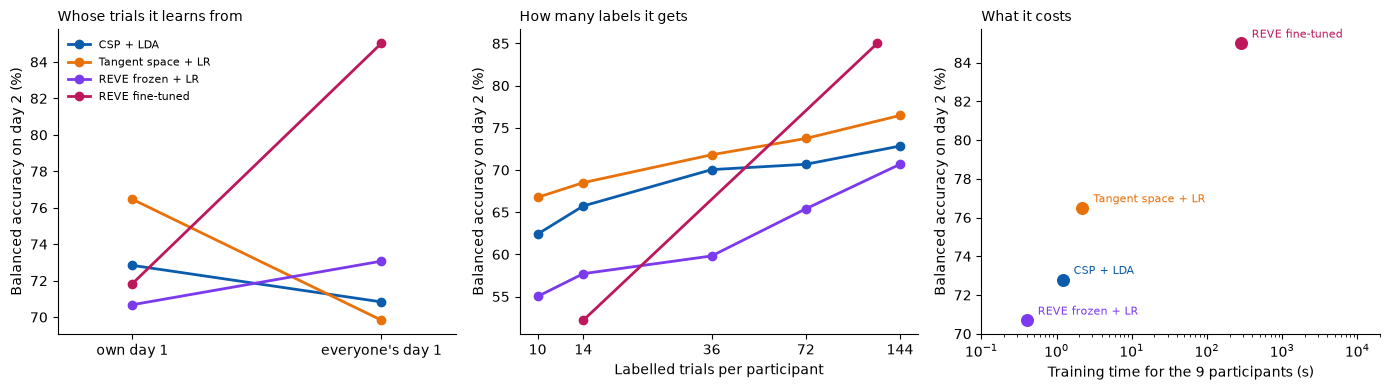

In [13]:
# ---- Training data, number of labels, and cost
pooled = pd.read_csv(RESULTS_DIR / "pooled.csv").groupby("method")["balanced_accuracy"].mean()
curve = pd.read_csv(RESULTS_DIR / "label_curve.csv", index_col="training_trials")
few = pd.read_csv(RESULTS_DIR / "fm_finetuned_10pct.csv")["balanced_accuracy"].mean()
saved = mf.load_precomputed("predictions")
alone = saved[saved["run"].str.endswith("alone")].groupby("subject").apply(
    lambda r: balanced_accuracy_score(r["label"], np.where(r["p_right"] > 0.5, "right_hand", "left_hand")),
    include_groups=False).mean()
own = table.mean(axis=1).copy()
own["REVE fine-tuned"], pooled["REVE fine-tuned"] = alone, table.loc["REVE fine-tuned"].mean()

mf.plot.conditions(own, pooled, curve, {14: few, 122: pooled["REVE fine-tuned"]}, summary["seconds"], summary["balanced_accuracy"])

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">What we see</b><br><b>Left.</b> Trained on one participant, the four decoders are within 5 points of each other, 71 to 76 %, and tangent space + LR is first. The fine-tuned REVE stands out only when it learns from everyone. The classical decoders lose from the same change.<br><b>Middle.</b> The classical decoders are ahead at every number of labels up to 72 per participant. The fine-tuned REVE is last with 14 labels per participant and first with all of them.<br><b>Right.</b> The classical decoders and the probe train in about 2 seconds or less for the nine participants. Fine-tuning takes more than 100 times longer and a GPU.</div>

## 6. So, who won?

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>There is no single winner on this dataset.</div>

<div style="border-left:5px solid #B45309; background:#FEF6E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#B45309;">Question</b><br>Go back to the prediction you made at the start of the session. What did you get right, and what surprised you?</div>

The answer depends on what you have.

- **One person, a laptop, a few minutes of labelled trials.** Tangent space + logistic regression. It is first among the decoders trained on one participant, at every number of labels, and it runs in seconds.
- **Labelled recordings from several people, and a GPU.** The fine-tuned REVE: 85 % on day 2, and the only decoder above chance for all nine participants.
- **The frozen REVE with a linear probe** is never first here. It is cheap once the embeddings exist, it improves when several people are pooled, and it decodes participant 7, whom the classical decoders miss.

So the question in the title has no single answer on this dataset. Pretraining did not replace labelled data: the pretrained model needed more of it than the classical decoders, and from several people. What it brought is a decoder that can learn from many people at once, which CSP and covariance matrices did not manage here. Benchmarks such as NeuralBench and EEG-FM-Compass ask the same question over many models and tasks: compare their conclusions with what you found here.

<div style="border-left:5px solid #E8710A; background:#FDF1E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#E8710A;">Watch out: the limits of this comparison</b><br>What this tutorial does not show. <b>One dataset</b>: nine people, one task, two classes, 22 electrodes. <b>One foundation model</b>, with one recipe for the probe and one for fine-tuning. <b>Classical decoders with default settings</b>, which specialists would tune further. <b>One run</b> of fine-tuning for the main score: part 7 looks at how much it moves from run to run. A different dataset, model or recipe can change the ranking, and published comparisons do not all agree for these reasons.</div>

## 7. Go further (optional)

### <span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> How much does one fine-tuning run depend on chance?

Fine-tuning starts from a random head and draws its batches at random. The package holds the same run repeated with other **random seeds**, and a second recipe (one stage, larger learning rate). Compute the mean day-2 score of each run. How does the spread between seeds compare with the gap between decoders?

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>mf.load_precomputed(&quot;predictions&quot;)</code> has the columns <code>run</code>, <code>seed</code>, <code>subject</code>, <code>label</code>, <code>p_right</code>. Keep the runs whose name starts with <code>&quot;all participants&quot;</code> and group by run, seed and subject.</div>

In [14]:
# ---- Type 3: day-2 score of every saved fine-tuning run, seed by seed (optional)

In [15]:
#@title Solution (try first)
# ---- Day-2 score of every saved fine-tuning run, seed by seed
runs = saved[saved["run"].isin(["all participants", "all participants, one stage"])]
per_subject = runs.groupby(["run", "seed", "subject"]).apply(
    lambda r: balanced_accuracy_score(r["label"], np.where(r["p_right"] > 0.5, "right_hand", "left_hand")),
    include_groups=False)
by_seed = (100 * per_subject.groupby(["run", "seed"]).mean()).unstack("seed").round(1)
by_seed["mean"], by_seed["lowest"], by_seed["highest"] = by_seed.mean(axis=1).round(1), by_seed.min(axis=1), by_seed.max(axis=1)
by_seed
# The two-stage recipe gives 84.6 to 85.2 % over four seeds: a spread of 0.6 points, small next to the 8.6 points
# that separate it from tangent space + LR. The one-stage recipe reaches 86 to 87 % three times and 65 % once.
# One run is not enough to compare two recipes.

seed,0,1,2,3,mean,lowest,highest
run,,,,,,,
all participants,85.0,85.2,84.6,84.6,84.8,84.6,85.2
"all participants, one stage",87.2,87.0,65.4,86.0,81.4,65.4,87.2


### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> A test on the values themselves

The Wilcoxon test looks at ranks. A **sign-flip permutation test** uses the values themselves. If two decoders were equally good, each participant's difference could as well have had the opposite sign. We flip the signs at random many times and count how often the mean is as far from 0 as the one we observed.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>signs * values</code> has one row per random draw and one column per participant: take the mean of each row with <code>.mean(axis=1)</code>. The p-value is the proportion of rows whose absolute mean is at least <code>abs(values.mean())</code>; the mean of an array of True/False is the proportion of True.</div>

In [16]:
# ---- Exercise: sign-flip permutation test on the nine differences
signs = np.random.default_rng(0).choice([-1, 1], size=(N_BOOTSTRAP, len(values)))    # one row of random signs per draw
flipped = ...                                        # <--- mean of each row of signs * values
p_permutation = ...                                  # <--- proportion of draws with abs(flipped) >= abs(values.mean())

In [17]:
#@title Solution (try first)
# ---- Sign-flip permutation test, fine-tuned REVE against the reference
signs = np.random.default_rng(0).choice([-1, 1], size=(N_BOOTSTRAP, len(values)))
flipped = (signs * values).mean(axis=1)
p_permutation = (np.abs(flipped) >= abs(values.mean())).mean()
print(f"Mean difference {values.mean():+.1f} points, permutation p = {p_permutation:.3f} (Wilcoxon: p = {result.pvalue:.3f})")
# The permutation test gives p = 0.13, close to the Wilcoxon test: with these nine participants the gain of the
# fine-tuned model over tangent space + LR could still be an accident of who took part.

Mean difference +8.6 points, permutation p = 0.129 (Wilcoxon: p = 0.172)


## 8. Summary

| Step | Function | Package |
|---|---|---|
| Gather the scores | `pd.read_csv`, `pd.concat`, `pivot` | pandas |
| Chance threshold | `stats.binom.ppf` | SciPy |
| Confidence interval | bootstrap with `rng.choice`, `np.percentile` | NumPy |
| Paired test | `stats.wilcoxon` | SciPy |
| Several tests | Holm correction | NumPy |

<div style="border-left:5px solid #15803D; background:#ECF8EF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#15803D;">Take-aways</b><br><ul style='margin:0;'><li>Fine-tuned on nine participants, REVE reaches 85 % on day 2; tangent space + LR, trained on one, 76 %; CSP + LDA 73 %; the frozen REVE 71 %.</li><li>The gain of fine-tuning comes from three participants. With nine people, the tests do not allow us to call it a general advantage.</li><li>With one participant, few labels or no GPU, the classical decoders are ahead.</li><li>A score means little without its conditions: the split, the training data, the number of labels, the compute, the random seed, and whether the test data was in the pretraining.</li></ul></div>

### Where to go from here

- **Four classes.** Add feet and tongue: `mf.load_epochs(classes=mf.data.ALL_CLASSES)`. Chance becomes 25 %.
- **A specialist deep network.** Train EEGNet or ShallowFBCSPNet from Braindecode on the same split: a network built for EEG, without pretraining.
- **Another foundation model.** The last exercise of notebook 3 swaps REVE for CBraMod. LaBraM and EEGPT load the same way.
- **Another dataset.** MOABB gives many motor-imagery datasets with the same interface. Check first whether your model saw them in pretraining.
- **The literature.** Benchmarks such as NeuralBench and EEG-FM-Compass run this kind of comparison over many models and tasks.

<details><summary>References</summary>

- Combrisson, E., & Jerbi, K. (2015). Exceeding chance level by chance: The caveat of theoretical chance levels in brain signal classification and statistical assessment of decoding accuracy. *Journal of Neuroscience Methods, 250*, 126-136. https://doi.org/10.1016/j.jneumeth.2015.01.010
- Demšar, J. (2006). Statistical comparisons of classifiers over multiple data sets. *Journal of Machine Learning Research, 7*, 1-30. https://jmlr.org/papers/v7/demsar06a.html
- Efron, B., & Tibshirani, R. J. (1993). *An introduction to the bootstrap*. Chapman & Hall.
- El Ouahidi, Y., Lys, J., Thölke, P., Farrugia, N., Pasdeloup, B., Gripon, V., Jerbi, K., & Lioi, G. (2025). REVE: A foundation model for EEG, adapting to any setup with large-scale pretraining on 25,000 subjects. *Advances in Neural Information Processing Systems 38*. https://arxiv.org/abs/2510.21585
- Holm, S. (1979). A simple sequentially rejective multiple test procedure. *Scandinavian Journal of Statistics, 6*(2), 65-70.
- Wilcoxon, F. (1945). Individual comparisons by ranking methods. *Biometrics Bulletin, 1*(6), 80-83. https://doi.org/10.2307/3001968
</details>